This notebook fits by-cre models on the shendure data & demonstrates that estimated nb parameters track closely with UMI means, as expected.

The matrix-creation and fitting code is independent of the main scMPRA package, since its this analysis that informed the package code.

# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
#imports
import pandas as pd
import numpy as np
import time
import pickle
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt

from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

In [4]:
#create dask cluster
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client = Client(cluster)

# Describe with an ortho

In [16]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial"

import os
if os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
else:
    print("[+] Model not found. Creating...")

    #load data
    data_root="/gpfs/gibbs/pi/reilly/tabula_data"
    shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_grouped.txt")
    shendure.set_negative_controls(["minP","noP"])
    shendure.set_reference_cell("Pluripotent")
    shendure.ortho_filter()

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                       dat=shendure)
    primordial.extract_params(client)
    primordial.save(path,name)


[+] Model found. Loading...


In [21]:
primordial.compute_model_qc()

regression error on Lama1_chr17_7892


# Examine QC metrics

TODO: check the one that failed.

Now that we've generated some QC metrics, let's examine them. First, let's look at the mu min & max : none should be below zero, none should be above 1000.

In [12]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 0.006043589964314243, max 479.622822172041
ct
min 0.0037471068262425774, max 446.0098699104508


All in the right ballpark!

Now let's look at the correlations.

---
low r Cdk5r1_chr11_12595
low r Lamc1_chr1_12183
low r Lamb1_chr12_2206
nan in Txndc12_chr4_7969
---
[0.991578965301733, 0.9999943541914857, 0.998503548868227, 0.9986942632779542, 0.9978530564909727, 0.9991786392120892, 0.9974631645724406, 0.9999224827329215, 0.9999898055384263, 0.9990784485045111, 0.9999930942794925, 0.996864043964435, 0.9996702383193294, 0.9982301422021405, 0.997812831115534, 0.9993918245624014, 0.999862189797376, 0.9999046234710616, 0.9749107960354325, 0.9878224662918991, 0.9992549912303406, 0.9988078390402064, 0.9997916663630924, 0.9952657081936039, 0.9928860605308873, 0.9988896674162807, 0.9997805531145812, 0.9944008510634161, 0.9991323018546729, 0.9999630684656111, 0.99861757916858, 0.9999993795011303, 0.9999128746620486, 0.9990074673106141, 0.9998886732687686, 0.9999828028541193, 0.9999861809862587, 0.9999547649435041, 0.9999998102977541, 0.9980113670966615, 0.999892863365974, 0.9870322778242185, 0.997991892736914, 0.9812924663748684, 0.9976867125839097, 0.99

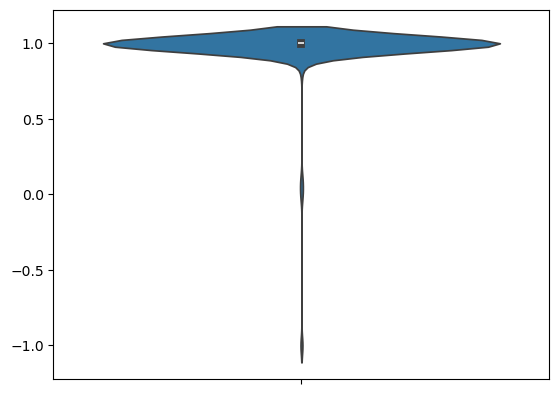

In [13]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

Correlations generally look pretty good. Let's examine the cases where they aren't.

Notably all of the bad ones are from the set of "by cell-type" models.

I'm going to guess these are low-expressing CREs. Let's take a look.

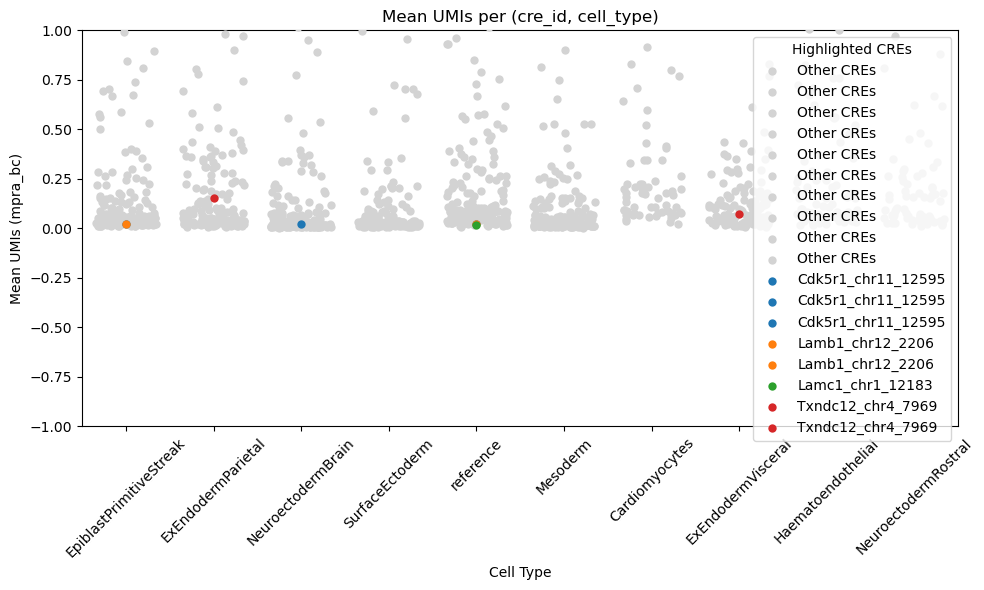

In [17]:
highlighted_cre_ids=["Cdk5r1_chr11_12595","Lamb1_chr12_2206","Lamc1_chr1_12183","Txndc12_chr4_7969"]

grouped = (
    shendure.data
    .groupby(["cre_id", "cell_type"])["umis_mpra_bc"]
    .mean()
    .reset_index()
)

# Split base vs. highlighted
base = grouped[~grouped["cre_id"].isin(highlighted_cre_ids)]
highlighted = grouped[grouped["cre_id"].isin(highlighted_cre_ids)]

# Set up plot
plt.figure(figsize=(10, 6))

# Plot base layer with jitter
sns.stripplot(
    data=base,
    x="cell_type",
    y="umis_mpra_bc",
    color="lightgray",
    jitter=0.35,
    label="Other CREs",
    size=6
)

# Overlay highlighted CREs with jitter and custom color
palette = sns.color_palette("tab10", n_colors=len(highlighted_cre_ids))
for i, cre in enumerate(highlighted_cre_ids):
    sns.stripplot(
        data=highlighted[highlighted["cre_id"] == cre],
        x="cell_type",
        y="umis_mpra_bc",
        color=palette[i],
        jitter=0.35,
        label=cre,
        size=6
    )

# Y-axis and aesthetics
plt.ylim(-1, 1)
plt.xlabel("Cell Type")
plt.ylabel("Mean UMIs (mpra_bc)")
plt.title("Mean UMIs per (cre_id, cell_type)")
plt.xticks(rotation=45)
plt.legend(title="Highlighted CREs")
plt.tight_layout()
plt.show()


In [22]:
primordial.by_cre_qc["Cdk5r1_chr11_12595"]

{'success': True,
 'dat':                                mu  mean(umis_mpra_bc)
 cell_type                                            
 EpiblastPrimitiveStreak  0.050800            0.021552
 NeuroectodermBrain       0.054830            0.023256
 reference                0.057373            0.021467,
 'slope': 0.28785064430406176,
 'intercept': 0.04797514051132486,
 'r_value': 0.0876519231974919,
 'p_value': 0.94412735263363,
 'std_err': 3.2713800650472793}